In [7]:
import pandas as pd
import numpy as np
import heapq
import matplotlib.pyplot as plt
import random
from joblib import Parallel, delayed
from src.evaluation import MAE

X_submit = pd.read_csv("data/processed/X_submit.csv")
y_train_holed = pd.read_csv("data/processed/y_train_holed.csv")
y_train_complete = pd.read_csv("data/processed/y_train_complete.csv")

In [33]:
X_train.head()

,Horodate,123476859,123596487,123798654,123875946,123879645,123897645,123947865,124367958,124568973,...,holed_989,holed_990,holed_992,holed_993,holed_994,holed_996,holed_997,holed_998,holed_999,holed_1000
0,2023-01-09 00:00:00,102.0,992.0,365.0,252.0,71.0,132.0,30.0,201.0,121.0,...,726.0,442.0,32.0,152.0,121.0,1099.0,117.0,45.0,253.0,186.0
1,2023-01-09 00:30:00,89.0,996.0,351.0,219.0,47.0,140.0,31.0,173.0,186.0,...,768.0,314.0,34.0,84.0,107.0,782.0,109.0,40.0,227.0,180.0
2,2023-01-09 01:00:00,134.0,841.0,314.0,213.0,55.0,114.0,38.0,204.0,251.0,...,1382.0,235.0,30.0,24.0,128.0,630.0,375.0,58.0,237.0,166.0
3,2023-01-09 01:30:00,130.0,961.0,228.0,253.0,35.0,103.0,35.0,176.0,305.0,...,1588.0,105.0,34.0,24.0,200.0,773.0,468.0,48.0,245.0,525.0
4,2023-01-09 02:00:00,135.0,949.0,213.0,243.0,47.0,472.0,21.0,187.0,283.0,...,1669.0,90.0,30.0,46.0,792.0,879.0,534.0,41.0,175.0,372.0


### Distance Euclidienne

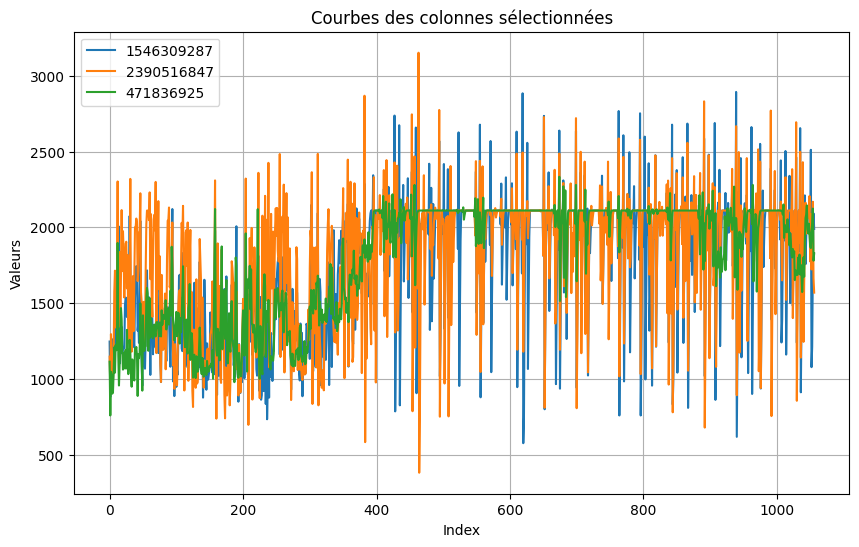

In [16]:
def partial_distance(serie, numeric_df_train, k):
    mean_abs_diff = numeric_df_train.sub(serie, axis=0).abs().mean(axis=0)

    mean_abs_diff = mean_abs_diff[mean_abs_diff > 1e-9]
    mean_abs_diff = mean_abs_diff.dropna()

    k_eff = min(k, len(mean_abs_diff))
    if k_eff == 0:
        return []

    closest_series = mean_abs_diff.nsmallest(k_eff)
    closest = list(closest_series.items())

    return closest

df = X_submit.drop(columns=["Horodate"], errors='ignore')
# Liste des noms de colonnes à tracer
ma_liste = df.columns
element_aleatoire = random.choice(ma_liste)
serie = df[element_aleatoire]
liste_colonnes = [element_aleatoire]
closest = partial_distance(serie, df, 2)
cols_plus_proches = [col for col, _ in closest]
liste_colonnes = liste_colonnes + cols_plus_proches

# Vérifier que les colonnes existent dans le DataFrame
colonnes_existantes = [col for col in liste_colonnes if col in df.columns]
if len(colonnes_existantes) != len(liste_colonnes):
    print("Certaines colonnes de la liste n'existent pas dans le DataFrame.")

# Tracer les courbes des colonnes sélectionnées
df[colonnes_existantes].plot(kind='line', figsize=(10, 6))
plt.xlabel("Index")
plt.ylabel("Valeurs")
plt.title("Courbes des colonnes sélectionnées")
plt.legend(colonnes_existantes)
plt.grid(True)
plt.show()


In [ ]:
def new_curve_with_knn(df_train, closest):
    cols_plus_proches = [col for col, _ in closest]
    distances = np.array([dist for _, dist in closest])

    weights = 1.0 / (distances + 1e-9)

    numeric_df_train = df_train.drop(columns=["Horodate"], errors='ignore')
    relevant_df = numeric_df_train[cols_plus_proches]

    weighted_sum = relevant_df.mul(weights, axis=1).sum(axis=1)
    sum_weights = weights.sum()

    if sum_weights > 1e-9:
        new_curve = weighted_sum / sum_weights
    else:
        new_curve = pd.Series(index=relevant_df.index, dtype=float)

    return new_curve

new_curve_with_knn(df, closest)


0       1129.5
1        856.0
2       1170.5
3       1084.0
4        950.5
         ...  
1052    1839.0
1053    1933.5
1054    2146.5
1055    1722.0
1056    1698.5
Length: 1057, dtype: float64

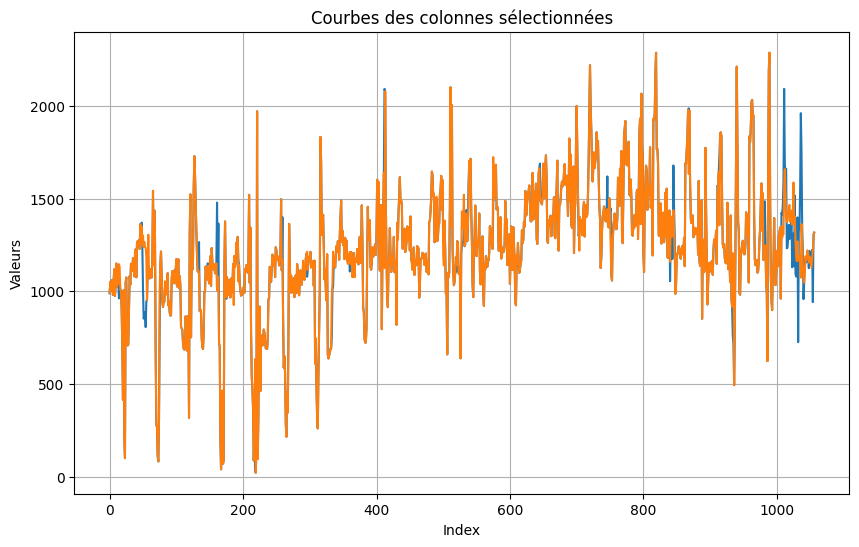

In [40]:
y_train_cols = y_train_holed[1:].columns
random_col = random.choice(y_train_cols)
serie_holed = y_train_holed[random_col]
k = 4

closest = partial_distance(serie_holed, X_submit, k)
new_curve = new_curve_with_knn(X_submit, closest)

serie_complete = serie_holed.fillna(new_curve)

real_serie = y_train_complete[random_col]
real_serie.plot(kind='line', figsize=(10, 6))
serie_complete.plot(kind='line', figsize=(10, 6))
plt.xlabel("Index")
plt.ylabel("Valeurs")
plt.title("Courbes des colonnes sélectionnées")
plt.grid(True)
plt.show()

In [18]:
def process_column(col_name, df_holed, numeric_df_train_full, k):
    #print(f"Processing column: {col_name}")
    serie_holed = df_holed[col_name]
    closest = partial_distance(serie_holed, numeric_df_train_full, k)
    new_col = new_curve_with_knn(numeric_df_train_full, closest)
    serie_complete = serie_holed.fillna(new_col)
    #print(f"  Finished column {col_name}")
    return serie_complete

def filled_with_knn(df_holed, df_train, k, n_jobs=-1):
    numeric_df_holed = df_holed.drop(columns=["Horodate"], errors='ignore')
    numeric_df_train = df_train.drop(columns=["Horodate"], errors='ignore')
    columns_to_process = numeric_df_holed.columns

    results = Parallel(n_jobs=n_jobs)(
        delayed(process_column)(col, numeric_df_holed, numeric_df_train, k)
        for col in columns_to_process
    )

    df_complete = pd.concat(results, axis=1)
    df_complete = df_complete[numeric_df_holed.columns]
    df_complete.insert(0, "Horodate", df_holed["Horodate"])

    return df_complete

maes = []
for k in range(10):
    df_pred = filled_with_knn(y_train_holed, X_submit, k, n_jobs=20)
    mae = MAE(y_train_complete, df_pred, y_train_holed)
    maes.append(mae)
maes


[nan,
 109.09829561859021,
 101.8001057069248,
 99.97229443691505,
 98.95681193925954,
 98.57445128109245,
 98.40255801486953,
 98.3547225778643,
 98.49944529888083,
 98.60185833140518]

distance pondéré : [nan,
 109.09829561859021,
 101.76490911887738,
 99.90443273230913,
 98.88230847956596,
 98.48832412388101,
 98.30500183041264,
 98.24292134405265,
 98.37657298965642,
 98.47369131049702]

### Distance DTW

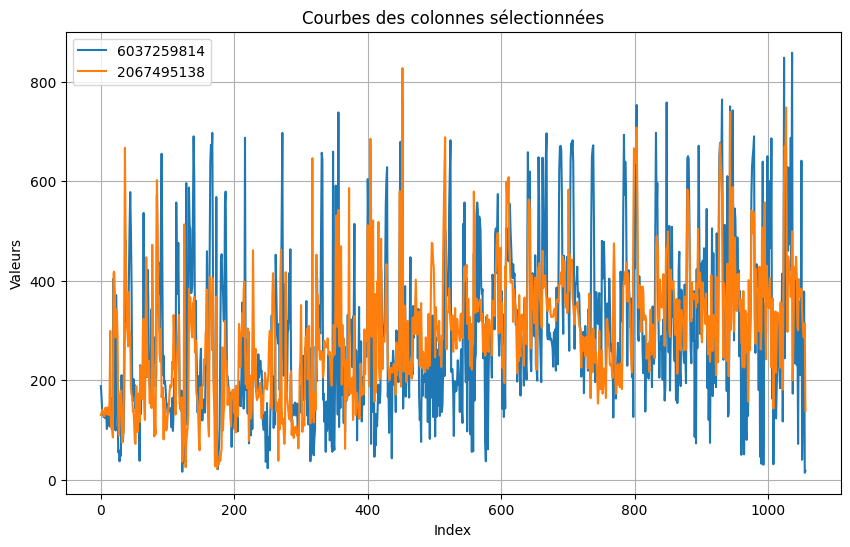

In [6]:
import numpy as np
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean

def k_distance_dtw(column_name, df, k):
    dict={}
    for col in df.columns:
        if (column_name != col) and (col != "Horodate"):
            s1 = np.array(df[column_name])
            s2 = np.array(df[col])
            distance, path = fastdtw(s1, s2, dist=lambda x, y: abs(x - y))
            dict[col] = distance
    return heapq.nsmallest(k, dict, key=dict.get)

df = X_train
# Liste des noms de colonnes à tracer
ma_liste = df.columns
element_aleatoire = random.choice(ma_liste)
liste_colonnes = [element_aleatoire]
liste_colonnes = liste_colonnes + k_distance_dtw(element_aleatoire, X_train, 1) # par exemple

# Vérifier que les colonnes existent dans le DataFrame
colonnes_existantes = [col for col in liste_colonnes if col in df.columns]
if len(colonnes_existantes) != len(liste_colonnes):
    print("Certaines colonnes de la liste n'existent pas dans le DataFrame.")

# Tracer les courbes des colonnes sélectionnées
df[colonnes_existantes].plot(kind='line', figsize=(10, 6))
plt.xlabel("Index")
plt.ylabel("Valeurs")
plt.title("Courbes des colonnes sélectionnées")
plt.legend(colonnes_existantes)
plt.grid(True)
plt.show()

